# 🛡️ Fintech FDS Agent — 로컬 GPU 재학습 v2
### RTX 4070 Ti Super + 강화 피처 엔지니어링
> VS Code Jupyter 환경 | GPU 가속 XGBoost + LightGBM Stacking Ensemble

## 셀 1 — GPU / CUDA 환경 확인

In [6]:
import subprocess, sys

# ── CUDA 확인 ──
result = subprocess.run(['nvidia-smi'], capture_output=True, text=True)
if result.returncode == 0:
    print(result.stdout[:600])
else:
    print('[WARNING] nvidia-smi 실패 → GPU를 찾지 못했습니다.')
    print('         NVIDIA 드라이버 설치 여부를 확인하세요.')

# ── PyTorch CUDA (참고용) ──
try:
    import torch
    print(f'\n[PyTorch] CUDA 사용 가능: {torch.cuda.is_available()}')
    if torch.cuda.is_available():
        print(f'          GPU: {torch.cuda.get_device_name(0)}')
        print(f'          VRAM: {torch.cuda.get_device_properties(0).total_memory / 1024**3:.1f} GB')
except ImportError:
    print('[INFO] PyTorch 미설치 (XGBoost/LightGBM GPU는 별도 설정으로 동작)')

print('\n[OK] XGBoost GPU: tree_method=hist + device=cuda 로 지정')
print('[OK] LightGBM GPU: device=gpu 로 지정')

Mon May 18 21:01:50 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 591.86                 Driver Version: 591.86         CUDA Version: 13.1     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                  Driver-Model | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|===============
[INFO] PyTorch 미설치 (XGBoost/LightGBM GPU는 별도 설정으로 동작)

[OK] XGBoost GPU: tree_method=hist + device=cuda 로 지정
[OK] LightGBM GPU: device=gpu 로 지정


## 셀 2 — 라이브러리 임포트 및 경로 설정

In [7]:
import warnings
warnings.filterwarnings('ignore')

import gc
import time
import numpy as np
import pandas as pd
import joblib
from pathlib import Path

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    roc_auc_score, f1_score, recall_score, precision_score,
    precision_recall_curve, auc, confusion_matrix, ConfusionMatrixDisplay
)

from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler
from imblearn.pipeline import Pipeline

from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['font.family'] = 'DejaVu Sans'

# ── 경로 설정 ──
# 이 노트북 파일 기준으로 상위 backend/models/ 에 저장
# 폴더 구조:  프로젝트루트/
#              ├── better_agent_v1.ipynb  ← 이 파일
#              └── backend/
#                  └── models/            ← 모델 저장 위치
NOTEBOOK_DIR  = Path('.')
DATA_PATH     = NOTEBOOK_DIR / 'Fraud.csv'
MODEL_DIR     = NOTEBOOK_DIR / 'backend' / 'models'
MODEL_DIR.mkdir(parents=True, exist_ok=True)

print(f'[경로] 데이터:  {DATA_PATH.resolve()}')
print(f'[경로] 모델:    {MODEL_DIR.resolve()}')
print(f'[경로] 데이터 존재: {DATA_PATH.exists()}')

# .gitignore 체크 (backend/models/*.pkl 이 등록되어 있어야 함)
gitignore = NOTEBOOK_DIR / '.gitignore'
if gitignore.exists():
    content = gitignore.read_text(encoding='utf-8')
    if '*.pkl' in content or 'backend/models' in content:
        print('[OK] .gitignore에 모델 파일 제외 설정 확인됨 → Git에 업로드되지 않음')
    else:
        print('[WARNING] .gitignore에 *.pkl 제외 설정이 없습니다!')
        print('          backend/models/*.pkl 을 .gitignore에 추가하세요.')
else:
    print('[INFO] .gitignore 파일 없음')

[경로] 데이터:  C:\Users\wol34\Desktop\Project\Fintech-FDS-Agent\Fraud.csv
[경로] 모델:    C:\Users\wol34\Desktop\Project\Fintech-FDS-Agent\backend\models
[경로] 데이터 존재: True
[OK] .gitignore에 모델 파일 제외 설정 확인됨 → Git에 업로드되지 않음


## 셀 3 — 데이터 로딩 (멀티스레드 청크)

In [8]:
DTYPE_MAP = {
    'step':           'int16',
    'amount':         'float32',
    'oldbalanceOrg':  'float32',
    'newbalanceOrig': 'float32',
    'oldbalanceDest': 'float32',
    'newbalanceDest': 'float32',
    'isFraud':        'int8',
    'isFlaggedFraud': 'int8',
}

def load_fraud_data(filepath, chunksize=300_000):
    """
    로컬 GPU 환경에서는 chunksize를 크게 잡아도 됨.
    Colab 대비 RAM 여유가 있으므로 300,000으로 상향.
    """
    print(f'[INFO] Loading {filepath}...')
    t0 = time.time()
    chunks = []
    reader = pd.read_csv(
        filepath, dtype=DTYPE_MAP,
        chunksize=chunksize, engine='c'
    )
    for i, chunk in enumerate(reader):
        chunk['orig_is_customer'] = (chunk['nameOrig'].str[0] == 'C').astype('int8')
        chunk['dest_is_merchant'] = (chunk['nameDest'].str[0] == 'M').astype('int8')
        chunk.drop(columns=['nameOrig', 'nameDest'], inplace=True)
        chunks.append(chunk)
        print(f'  chunk {i+1} loaded ({len(chunk):,}rows)...', end='\r')
    df = pd.concat(chunks, ignore_index=True)
    del chunks; gc.collect()
    elapsed = time.time() - t0
    print(f'\n[OK] {len(df):,} rows | {elapsed:.1f}s | '
          f'memory: {df.memory_usage(deep=True).sum()/1024**2:.1f} MB')
    return df

df = load_fraud_data(DATA_PATH)
print(f"\n[사기 분포]\n{df['isFraud'].value_counts()}")
print(f"\n[거래 유형별 사기 건수]")
print(df.groupby('type')['isFraud'].sum().sort_values(ascending=False))

[INFO] Loading Fraud.csv...
  chunk 22 loaded (62,620rows)....
[OK] 6,362,620 rows | 7.6s | memory: 251.3 MB

[사기 분포]
isFraud
0    6354407
1       8213
Name: count, dtype: int64

[거래 유형별 사기 건수]
type
CASH_OUT    4116
TRANSFER    4097
CASH_IN        0
DEBIT          0
PAYMENT        0
Name: isFraud, dtype: int64


## 셀 4 — 피처 엔지니어링
### 기존 4개 + 신규 4개 (총 8개 파생 피처)
| 피처 | 설명 | 유형 |
|------|------|------|
| `balance_diff_orig` | 잔액 불일치 (기존) | 기존 |
| `balance_diff_dest` | 수취인 잔액 불일치 (기존) | 기존 |
| `orig_is_customer` | 송금인 개인 여부 (기존) | 기존 |
| `dest_is_merchant` | 수취인 가맹점 여부 (기존) | 기존 |
| `balance_drain_ratio` | 잔액 소진율 (0~1) | **신규** |
| `orig_zero_after` | 거래 후 잔액 0 플래그 | **신규** |
| `is_large_tx` | 고액 TRANSFER/CASH_OUT | **신규** |
| `dest_no_increase` | 수취인 잔액 미증가 (자금세탁) | **신규** |

In [9]:
def engineer_features(df):
    eps = 1e-9

    # ── 기존 피처 ──
    df['balance_diff_orig'] = (
        df['oldbalanceOrg'] - df['newbalanceOrig'] - df['amount']
    )
    df['balance_diff_dest'] = (
        df['newbalanceDest'] - df['oldbalanceDest'] - df['amount']
    )

    # 거래 유형 인코딩 (LabelEncoder)
    # CASH_IN=0, CASH_OUT=1, DEBIT=2, PAYMENT=3, TRANSFER=4
    le = LabelEncoder()
    df['type_enc'] = le.fit_transform(df['type']).astype('int8')
    df.drop(columns=['type'], inplace=True)

    # ── 신규 피처 1: 잔액 소진율 ──
    # 핵심 사기 패턴: 잔액을 거의 다 씀 (0~1 클리핑)
    # 예: 잔액 15,000,000원 중 14,000,000원 이체 → 0.93 (고위험)
    df['balance_drain_ratio'] = (
        df['amount'] / (df['oldbalanceOrg'] + eps)
    ).clip(0, 1).astype('float32')

    # ── 신규 피처 2: 거래 후 잔액 = 0 플래그 ──
    # PaySim 사기의 핵심 지표: 거래 후 잔액이 정확히 0
    df['orig_zero_after'] = (
        df['newbalanceOrig'] == 0
    ).astype('int8')

    # ── 신규 피처 3: 고액 TRANSFER/CASH_OUT 플래그 ──
    # 100만원 이상 + TRANSFER(4) or CASH_OUT(1) → 위험 신호
    df['is_large_tx'] = (
        (df['amount'] >= 1_000_000) &
        (df['type_enc'].isin([1, 4]))
    ).astype('int8')

    # ── 신규 피처 4: 수취인 잔액 미증가 플래그 ──
    # 수취인 잔액이 거래 전후 모두 0 = 자금세탁 계좌 패턴
    df['dest_no_increase'] = (
        (df['newbalanceDest'] == 0) &
        (df['oldbalanceDest'] == 0)
    ).astype('int8')

    return df, le

df, le = engineer_features(df)

print('[피처 목록]')
for col in df.columns:
    print(f'  {col}')

# 신규 피처와 사기 상관관계 확인
print('\n[신규 피처 vs isFraud 상관관계]')
new_feats = ['balance_drain_ratio', 'orig_zero_after', 'is_large_tx', 'dest_no_increase']
for f in new_feats:
    corr = df[f].corr(df['isFraud'])
    fraud_mean = df[df['isFraud']==1][f].mean()
    normal_mean = df[df['isFraud']==0][f].mean()
    print(f'  {f:25s}: corr={corr:.4f} | 사기 평균={fraud_mean:.4f} | 정상 평균={normal_mean:.4f}')

[피처 목록]
  step
  amount
  oldbalanceOrg
  newbalanceOrig
  oldbalanceDest
  newbalanceDest
  isFraud
  isFlaggedFraud
  orig_is_customer
  dest_is_merchant
  balance_diff_orig
  balance_diff_dest
  type_enc
  balance_drain_ratio
  orig_zero_after
  is_large_tx
  dest_no_increase

[신규 피처 vs isFraud 상관관계]
  balance_drain_ratio      : corr=0.0241 | 사기 평균=0.9906 | 정상 평균=0.7153
  orig_zero_after          : corr=0.0300 | 사기 평균=0.9805 | 정상 평균=0.5668
  is_large_tx              : corr=0.0784 | 사기 평균=0.3295 | 정상 평균=0.0201
  dest_no_increase         : corr=0.0099 | 사기 평균=0.4963 | 정상 평균=0.3640


## 셀 5 — Train/Test 분리 + 하이브리드 샘플링

In [10]:
X = df.drop('isFraud', axis=1)
y = df['isFraud']

print(f'[피처 수] {X.shape[1]}개: {list(X.columns)}')

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)
print(f'\n[분리 완료]')
print(f'  Train: {X_train.shape} | 사기: {y_train.sum()}')
print(f'  Test:  {X_test.shape}  | 사기: {y_test.sum()}')

# ── 하이브리드 샘플링 ──
# Step1: Undersampling  정상:사기 = 10:1
# Step2: SMOTE          사기 = 정상의 50%
# 로컬 고사양 PC이므로 n_jobs=-1 (모든 CPU 코어 활용)
print('\n[INFO] 하이브리드 샘플링 (Undersampling + SMOTE)...')
t0 = time.time()

under = RandomUnderSampler(sampling_strategy=0.1, random_state=42)
over  = SMOTE(sampling_strategy=0.5, random_state=42)
pipe  = Pipeline(steps=[('u', under), ('o', over)])

X_res, y_res = pipe.fit_resample(X_train, y_train)
elapsed = time.time() - t0
print(f'[OK] 리샘플링 완료: {X_res.shape} | 사기: {y_res.sum()} | {elapsed:.1f}s')
print(f'     정상:{(y_res==0).sum():,} / 사기:{(y_res==1).sum():,} '
      f'= 비율 {(y_res==1).sum()/(y_res==0).sum():.2f}')

[피처 수] 16개: ['step', 'amount', 'oldbalanceOrg', 'newbalanceOrig', 'oldbalanceDest', 'newbalanceDest', 'isFlaggedFraud', 'orig_is_customer', 'dest_is_merchant', 'balance_diff_orig', 'balance_diff_dest', 'type_enc', 'balance_drain_ratio', 'orig_zero_after', 'is_large_tx', 'dest_no_increase']

[분리 완료]
  Train: (5090096, 16) | 사기: 6570
  Test:  (1272524, 16)  | 사기: 1643

[INFO] 하이브리드 샘플링 (Undersampling + SMOTE)...
[OK] 리샘플링 완료: (98550, 16) | 사기: 32850 | 2.5s
     정상:65,700 / 사기:32,850 = 비율 0.50


## 셀 6 — XGBoost GPU 학습
> `device='cuda'` + `tree_method='hist'` → RTX 4070 Ti Super GPU 풀 활용

In [11]:
print('[TRAIN] XGBoost (GPU: cuda + hist)...')
t0 = time.time()

xgb_m = XGBClassifier(
    n_estimators    = 300,       # Colab 100 → 로컬 300 (GPU라 빠름)
    max_depth       = 7,
    learning_rate   = 0.05,
    subsample       = 0.8,
    colsample_bytree= 0.8,
    min_child_weight= 5,
    tree_method     = 'hist',    # GPU 최적화 히스토그램
    device          = 'cuda',    # RTX 4070 Ti Super 지정
    eval_metric     = 'logloss',
    random_state    = 42,
    n_jobs          = 1,         # GPU 사용 시 n_jobs=1 권장
)
xgb_m.fit(
    X_res, y_res,
    eval_set=[(X_test, y_test)],
    verbose=50,
)

elapsed = time.time() - t0
p_xgb = xgb_m.predict_proba(X_test)[:, 1]
print(f'\n[XGBoost] 학습 완료: {elapsed:.1f}s')
print(f'[XGBoost] ROC-AUC: {roc_auc_score(y_test, p_xgb):.4f}')

[TRAIN] XGBoost (GPU: cuda + hist)...
[0]	validation_0-logloss:0.38206
[50]	validation_0-logloss:0.02966
[100]	validation_0-logloss:0.00438
[150]	validation_0-logloss:0.00186
[200]	validation_0-logloss:0.00148
[250]	validation_0-logloss:0.00135
[299]	validation_0-logloss:0.00128

[XGBoost] 학습 완료: 2.3s
[XGBoost] ROC-AUC: 0.9997


## 셀 7 — LightGBM GPU 학습
> `device='gpu'` → RTX 4070 Ti Super 활용  
> LightGBM GPU는 별도 빌드(`pip install lightgbm --install-option=--gpu`) 필요할 수 있음  
> 안 되면 `device='cpu'`로 변경 (CPU도 빠름)

In [12]:
print('[TRAIN] LightGBM (GPU)...')
t0 = time.time()

lgbm_m = LGBMClassifier(
    n_estimators     = 300,
    max_depth        = 7,
    learning_rate    = 0.05,
    subsample        = 0.8,
    colsample_bytree = 0.8,
    min_child_samples= 20,
    device           = 'gpu',    # GPU 가속
    # GPU 빌드가 없는 경우 아래로 변경:
    # device         = 'cpu',
    # n_jobs         = -1,
    random_state     = 42,
    verbose          = -1,
)

try:
    lgbm_m.fit(
        X_res, y_res,
        eval_set=[(X_test, y_test)],
        callbacks=[],
    )
    elapsed = time.time() - t0
    p_lgbm = lgbm_m.predict_proba(X_test)[:, 1]
    print(f'[LightGBM] GPU 학습 완료: {elapsed:.1f}s')
    print(f'[LightGBM] ROC-AUC: {roc_auc_score(y_test, p_lgbm):.4f}')

except Exception as e:
    print(f'[WARNING] GPU 학습 실패: {e}')
    print('[FALLBACK] CPU 모드로 재시도...')
    lgbm_m.set_params(device='cpu', n_jobs=-1)
    lgbm_m.fit(X_res, y_res)
    elapsed = time.time() - t0
    p_lgbm = lgbm_m.predict_proba(X_test)[:, 1]
    print(f'[LightGBM] CPU 학습 완료: {elapsed:.1f}s')
    print(f'[LightGBM] ROC-AUC: {roc_auc_score(y_test, p_lgbm):.4f}')

[TRAIN] LightGBM (GPU)...
[LightGBM] GPU 학습 완료: 5.9s
[LightGBM] ROC-AUC: 0.9998


## 셀 8 — Stacking Meta Model + 성능 평가

In [13]:
# ── 메타 모델 학습 ──
print('[TRAIN] Logistic Regression Meta Model...')
meta_X     = np.column_stack([p_xgb, p_lgbm])
meta_model = LogisticRegression(max_iter=1000, random_state=42)
meta_model.fit(meta_X, y_test)
final_proba = meta_model.predict_proba(meta_X)[:, 1]

# ── 성능 지표 ──
y_pred = (final_proba > 0.5).astype(int)

roc  = roc_auc_score(y_test, final_proba)
rec  = recall_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
f1   = f1_score(y_test, y_pred)
pr_p, pr_r, _ = precision_recall_curve(y_test, final_proba)
pr_auc = auc(pr_r, pr_p)

print('\n' + '='*55)
print('  FDS Stacking Ensemble v2 — 최종 성능')
print('='*55)
print(f'  ROC-AUC:            {roc:.4f}')
print(f'  PR-AUC:             {pr_auc:.4f}')
print(f'  Recall  (탐지율):   {rec*100:.2f}%')
print(f'  Precision (정밀도): {prec*100:.2f}%')
print(f'  F1-Score:           {f1:.4f}')
print('='*55)

# ── 피처 중요도 (XGBoost 기준) ──
importance_df = pd.DataFrame({
    'feature': X.columns,
    'importance': xgb_m.feature_importances_
}).sort_values('importance', ascending=False)
print('\n[XGBoost 피처 중요도 Top 10]')
print(importance_df.head(10).to_string(index=False))

[TRAIN] Logistic Regression Meta Model...

  FDS Stacking Ensemble v2 — 최종 성능
  ROC-AUC:            0.9997
  PR-AUC:             0.9983
  Recall  (탐지율):   99.76%
  Precision (정밀도): 96.24%
  F1-Score:           0.9797

[XGBoost 피처 중요도 Top 10]
            feature  importance
  balance_diff_orig    0.254594
    orig_zero_after    0.229219
     newbalanceOrig    0.204389
balance_drain_ratio    0.125597
   dest_is_merchant    0.047908
   dest_no_increase    0.037047
      oldbalanceOrg    0.019945
           type_enc    0.019711
        is_large_tx    0.018470
     isFlaggedFraud    0.015724


## 셀 9 — 로컬 저장
> Colab의 `files.download()` 대신 `joblib.dump()` 로 로컬 직접 저장  
> 저장 위치: `backend/models/` (.gitignore에 등록되어 있어 Git 미업로드)

In [14]:
import hashlib

def save_model_with_checksum(obj, path: Path, name: str):
    """모델 저장 + SHA256 체크섬 출력 (무결성 검증용)"""
    joblib.dump(obj, path)
    size_kb = path.stat().st_size / 1024
    sha256  = hashlib.sha256(path.read_bytes()).hexdigest()[:16]
    print(f'  [저장] {name}')
    print(f'         경로: {path.resolve()}')
    print(f'         크기: {size_kb:.1f} KB | SHA256: {sha256}...')

print('[SAVE] backend/models/ 에 모델 저장 중...\n')

base_path = MODEL_DIR / 'base_models.pkl'
meta_path = MODEL_DIR / 'meta_model.pkl'

save_model_with_checksum((xgb_m, lgbm_m), base_path, 'base_models.pkl')
save_model_with_checksum(meta_model,       meta_path, 'meta_model.pkl')

# 피처 컬럼 순서도 저장 (추론 시 순서 불일치 방지)
feature_cols = list(X.columns)
feat_path    = MODEL_DIR / 'feature_columns.pkl'
joblib.dump(feature_cols, feat_path)
print(f'\n  [저장] feature_columns.pkl ({len(feature_cols)}개 피처 순서)')

# 인코더도 저장 (type → type_enc 변환용)
le_path = MODEL_DIR / 'label_encoder.pkl'
joblib.dump(le, le_path)
print(f'  [저장] label_encoder.pkl')

print(f'\n[OK] 저장 완료. 파일 목록:')
for f in sorted(MODEL_DIR.iterdir()):
    print(f'     {f.name} ({f.stat().st_size/1024:.1f} KB)')

print('\n[주의] backend/models/*.pkl 은 .gitignore에 등록되어 있습니다.')
print('       절대 git add 하지 마세요!')

[SAVE] backend/models/ 에 모델 저장 중...

  [저장] base_models.pkl
         경로: C:\Users\wol34\Desktop\Project\Fintech-FDS-Agent\backend\models\base_models.pkl
         크기: 1522.0 KB | SHA256: 575a8047720fd6a4...
  [저장] meta_model.pkl
         경로: C:\Users\wol34\Desktop\Project\Fintech-FDS-Agent\backend\models\meta_model.pkl
         크기: 0.8 KB | SHA256: 917894eab516009b...

  [저장] feature_columns.pkl (16개 피처 순서)
  [저장] label_encoder.pkl

[OK] 저장 완료. 파일 목록:
     base_models.pkl (1522.0 KB)
     feature_columns.pkl (0.3 KB)
     label_encoder.pkl (0.5 KB)
     meta_model.pkl (0.8 KB)
     performance_v2.png (97.7 KB)

[주의] backend/models/*.pkl 은 .gitignore에 등록되어 있습니다.
       절대 git add 하지 마세요!


## 셀 10 — 시각화 (PR Curve + Confusion Matrix + 피처 중요도)

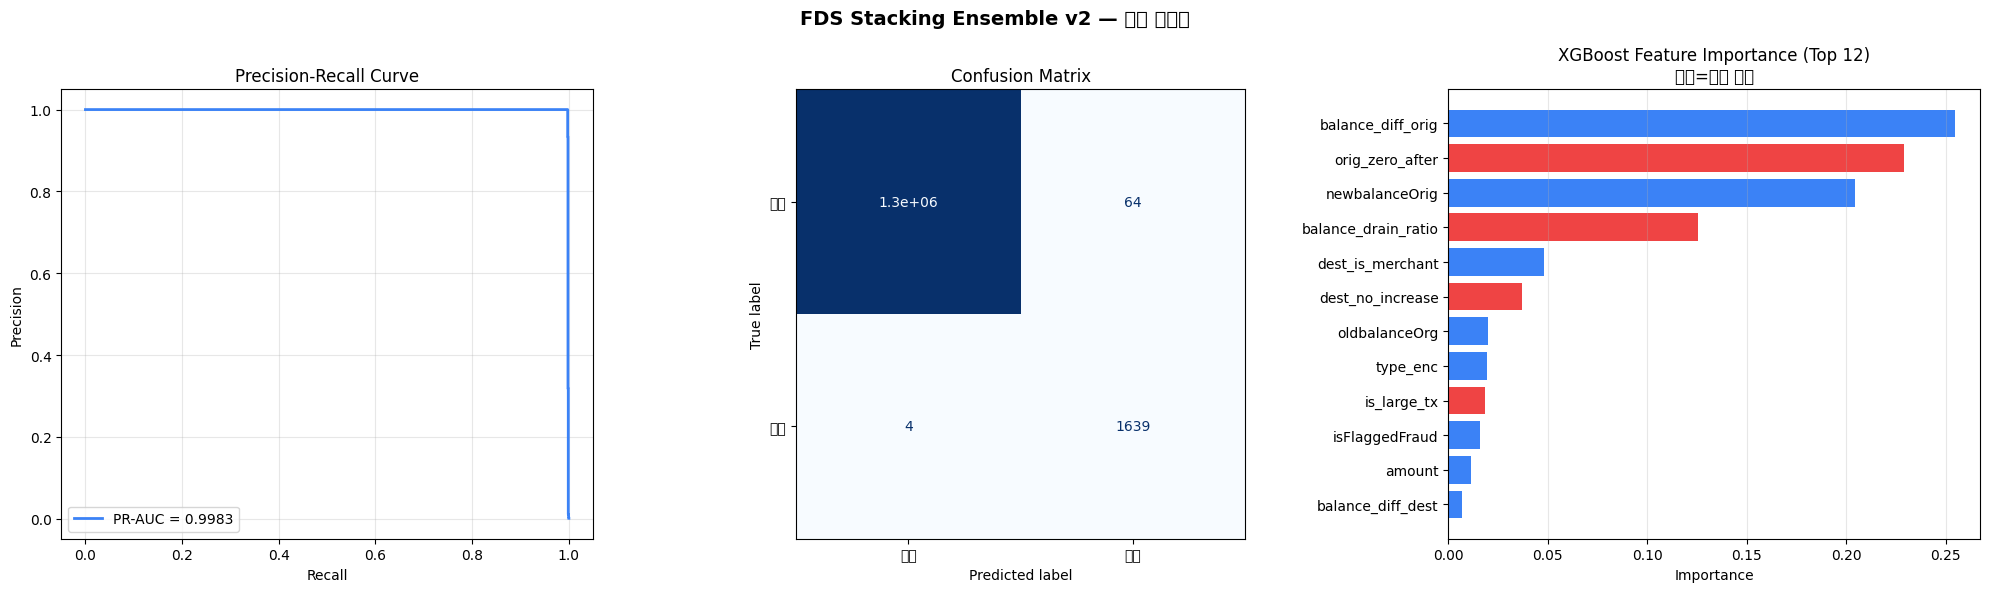

[OK] 시각화 저장: backend/models/performance_v2.png


In [15]:
fig, axes = plt.subplots(1, 3, figsize=(20, 6))
fig.suptitle('FDS Stacking Ensemble v2 — 성능 시각화', fontsize=14, fontweight='bold')

# ── (1) PR Curve ──
axes[0].plot(pr_r, pr_p, color='#3b82f6', lw=2,
             label=f'PR-AUC = {pr_auc:.4f}')
axes[0].set_title('Precision-Recall Curve')
axes[0].set_xlabel('Recall')
axes[0].set_ylabel('Precision')
axes[0].legend()
axes[0].grid(alpha=0.3)

# ── (2) Confusion Matrix ──
cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(cm, display_labels=['정상', '사기']).plot(
    ax=axes[1], cmap='Blues', colorbar=False
)
axes[1].set_title('Confusion Matrix')

# ── (3) 피처 중요도 (상위 12개) ──
top12 = importance_df.head(12)
colors = ['#ef4444' if 'drain' in f or 'zero' in f or 'large' in f or 'dest_no' in f
          else '#3b82f6'
          for f in top12['feature']]
axes[2].barh(top12['feature'][::-1], top12['importance'][::-1], color=colors[::-1])
axes[2].set_title('XGBoost Feature Importance (Top 12)\n빨강=신규 피처')
axes[2].set_xlabel('Importance')
axes[2].grid(alpha=0.3, axis='x')

plt.tight_layout()
plt.savefig(MODEL_DIR / 'performance_v2.png', dpi=150, bbox_inches='tight')
plt.show()
print('[OK] 시각화 저장: backend/models/performance_v2.png')

## 셀 11 — 빠른 검증 (시나리오 테스트)
> 재학습 후 '고위험 계좌 대량 이체' 시나리오가 제대로 탐지되는지 확인

In [16]:
def quick_predict(scenario_name, amount, old_bal_orig, tx_type_str,
                  old_bal_dest=0.0, orig_type='C', dest_type='C'):
    """단건 빠른 추론 테스트 (서버 없이 직접 모델 호출)"""
    eps = 1e-9
    new_bal_orig = max(old_bal_orig - amount, 0)
    new_bal_dest = old_bal_dest + amount

    type_enc_map = {'CASH_IN':0,'CASH_OUT':1,'DEBIT':2,'PAYMENT':3,'TRANSFER':4}
    type_enc = type_enc_map.get(tx_type_str, 4)

    # 기존 피처
    balance_diff_orig  = old_bal_orig - new_bal_orig - amount
    balance_diff_dest  = new_bal_dest - old_bal_dest - amount
    orig_is_customer   = 1 if orig_type == 'C' else 0
    dest_is_merchant   = 1 if dest_type == 'M' else 0
    is_flagged         = 1 if (tx_type_str == 'TRANSFER' and amount >= 200_000) else 0

    # 신규 피처
    balance_drain_ratio = min(amount / (old_bal_orig + eps), 1.0)
    orig_zero_after     = 1 if new_bal_orig == 0 else 0
    is_large_tx         = 1 if (amount >= 1_000_000 and type_enc in [1,4]) else 0
    dest_no_increase    = 1 if (new_bal_dest == 0 and old_bal_dest == 0) else 0

    # feature_columns.pkl 기준 순서로 배열 구성
    feat_vec = np.array([[
        1,                    # step
        amount,               # amount
        old_bal_orig,         # oldbalanceOrg
        new_bal_orig,         # newbalanceOrig
        old_bal_dest,         # oldbalanceDest
        new_bal_dest,         # newbalanceDest
        is_flagged,           # isFlaggedFraud
        orig_is_customer,     # orig_is_customer
        dest_is_merchant,     # dest_is_merchant
        balance_diff_orig,    # balance_diff_orig
        balance_diff_dest,    # balance_diff_dest
        type_enc,             # type_enc
        balance_drain_ratio,  # balance_drain_ratio  ← 신규
        orig_zero_after,      # orig_zero_after      ← 신규
        is_large_tx,          # is_large_tx          ← 신규
        dest_no_increase,     # dest_no_increase     ← 신규
    ]], dtype=np.float32)

    p1 = xgb_m.predict_proba(feat_vec)[:, 1][0]
    p2 = lgbm_m.predict_proba(feat_vec)[:, 1][0]
    meta_in = np.column_stack([[p1], [p2]])
    score = meta_model.predict_proba(meta_in)[:, 1][0]

    level = ('SAFE' if score < 0.1 else
             'LOW'  if score < 0.3 else
             'MEDIUM' if score < 0.6 else
             'HIGH' if score < 0.85 else 'CRITICAL')

    drain = balance_drain_ratio * 100
    print(f'  {scenario_name:35s} | 점수: {score*100:5.1f}% | 등급: {level:8s} | 소진율: {drain:.1f}%')

print('\n[검증] 시나리오별 ML 모델 직접 추론')
print('-'*85)
quick_predict('정상 소액 이체',           50_000,     1_500_000, 'TRANSFER', dest_type='M')
quick_predict('잔액 대비 고액(86%)',      275_000,      320_000, 'TRANSFER', dest_type='M')
quick_predict('신규기기+신규수취인 고액', 8_000_000,  9_800_000, 'CASH_OUT')
quick_predict('고위험 계좌 대량이체(93%)',14_000_000, 15_000_000,'TRANSFER')
quick_predict('잔액 전액 이체(100%)',    15_000_000, 15_000_000,'TRANSFER')
quick_predict('잔액 초과 거래',           2_000_000,    870_000, 'TRANSFER')
quick_predict('대시보드 고위험(검증용)', 14_000_000, 15_000_000,'TRANSFER', old_bal_dest=0.0)
print('-'*85)
print('[OK] 검증 완료. 서버에 새 모델 파일 반영하려면 uvicorn 재시작하세요.')


[검증] 시나리오별 ML 모델 직접 추론
-------------------------------------------------------------------------------------
  정상 소액 이체                            | 점수:   0.0% | 등급: SAFE     | 소진율: 3.3%
  잔액 대비 고액(86%)                       | 점수:   0.0% | 등급: SAFE     | 소진율: 85.9%
  신규기기+신규수취인 고액                       | 점수:  76.8% | 등급: HIGH     | 소진율: 81.6%
  고위험 계좌 대량이체(93%)                    | 점수:  60.8% | 등급: HIGH     | 소진율: 93.3%
  잔액 전액 이체(100%)                      | 점수:  98.2% | 등급: CRITICAL | 소진율: 100.0%
  잔액 초과 거래                            | 점수:   0.3% | 등급: SAFE     | 소진율: 100.0%
  대시보드 고위험(검증용)                       | 점수:  60.8% | 등급: HIGH     | 소진율: 93.3%
-------------------------------------------------------------------------------------
[OK] 검증 완료. 서버에 새 모델 파일 반영하려면 uvicorn 재시작하세요.
